In [1]:
import pandas as pd
import rasterio
import matplotlib.pyplot as plt

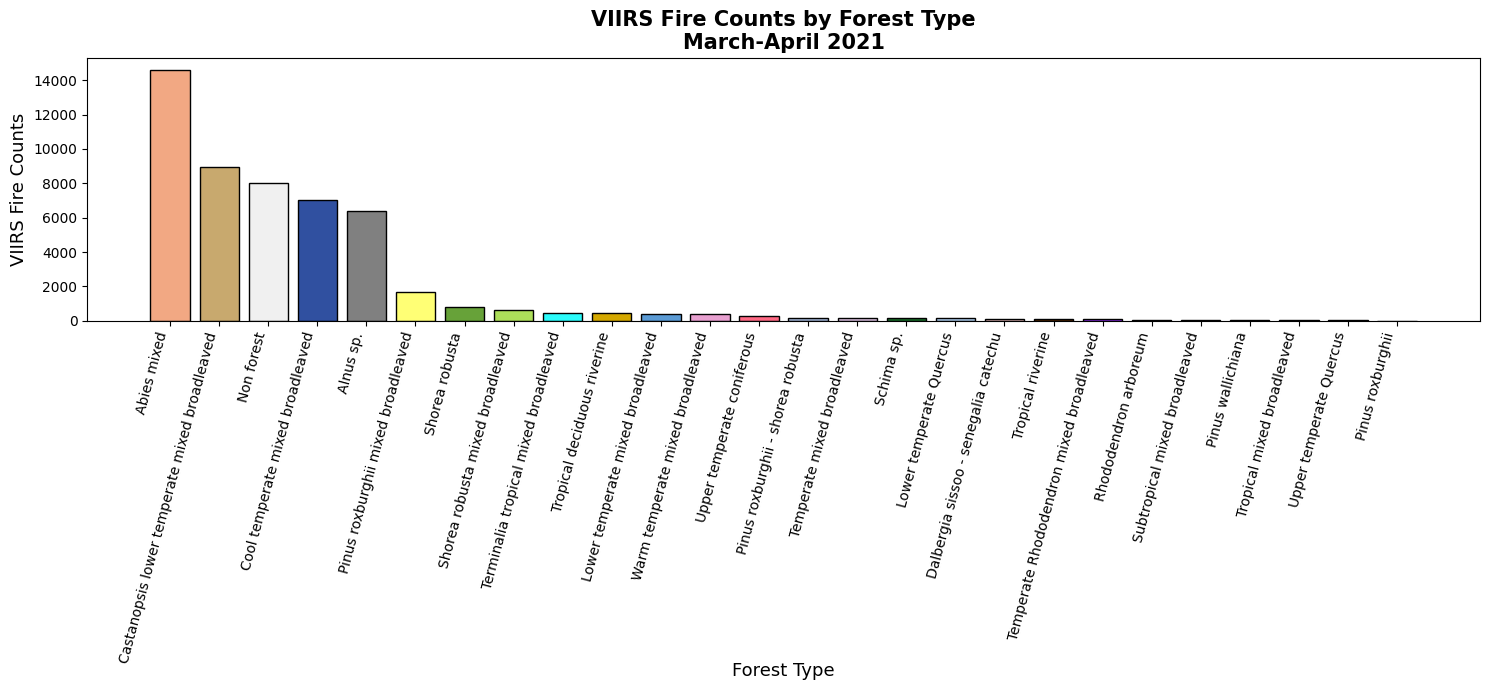

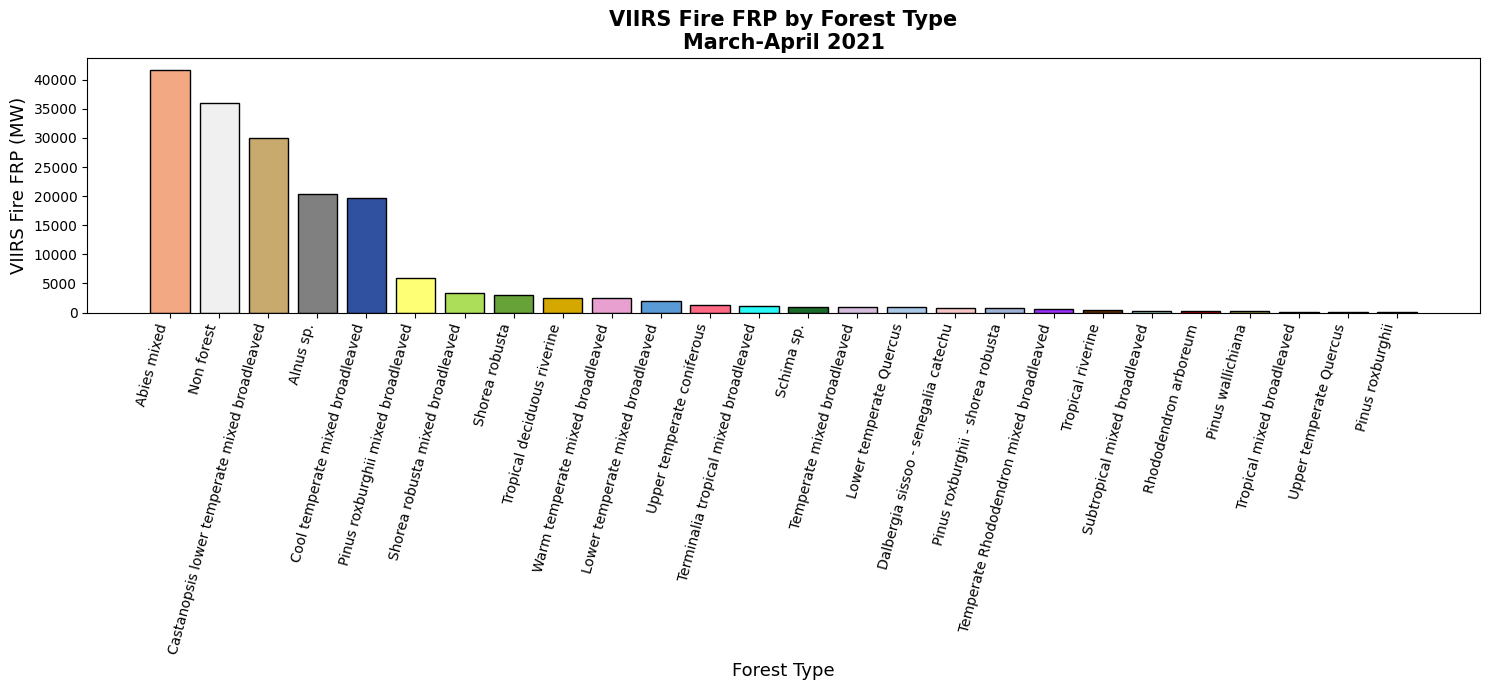

In [3]:
tifFile = "/Users/anehernandezarista/Holmes Summer 2026/Forest Types of Nepal/data/NepalForestType.tif"
viirs = "/Users/anehernandezarista/Holmes Summer 2026/fire_archive_SV-C2_760260.xlsx"

forest_types = {
1:  ("Abies mixed", "#F2A883"),
2:  ("Alnus sp.", "#808080"),
3:  ("Castanopsis lower temperate mixed broadleaved", "#C8A96E"),
4:  ("Cool temperate mixed broadleaved", "#3050A0"),
5:  ("Dalbergia sissoo - senegalia catechu", "#F5C4C4"),
6:  ("Lower temperate mixed broadleaved", "#5B9BD5"),
7:  ("Lower temperate Quercus", "#A8C8E8"),
8:  ("Pinus roxburghii", "#FFFFBF"),
9:  ("Pinus roxburghii mixed broadleaved", "#FFFF75"),
10: ("Pinus roxburghii - shorea robusta", "#A0B2D4"),
11: ("Pinus wallichiana", "#A0A046"),
12: ("Rhododendron arboreum", "#CC0000"),
13: ("Schima sp.", "#1A6B2A"),
14: ("Shorea robusta", "#67A239"),
15: ("Shorea robusta mixed broadleaved", "#ADDE5A"),
16: ("Subtropical mixed broadleaved", "#ACDDD1"),
17: ("Temperate mixed broadleaved", "#D6BCDC"),
18: ("Temperate Rhododendron mixed broadleaved", "#9B30FF"),
19: ("Terminalia tropical mixed broadleaved", "#2BFAFA"),
20: ("Tropical deciduous riverine", "#D4A800"),
21: ("Tropical mixed broadleaved", "#996600"),
22: ("Tropical riverine", "#5C2A00"),
23: ("Upper temperate coniferous", "#FF6984"),
24: ("Upper temperate Quercus", "#7B3FB5"),
25: ("Warm temperate mixed broadleaved", "#E8A0D0"),
26: ("Non forest", "#F0F0F0"),
}

viirs = pd.read_excel(viirs)

viirs = viirs[viirs["confidence"].isin(["n", "h"])].copy() #KEEP ONLY N AND H CONFIDENCE LEVELS

viirs = viirs.dropna(subset=["latitude", "longitude", "frp"]).copy()
viirs["firecount"] = 1

with rasterio.open(tifFile) as src:
    coords = list(zip(viirs["longitude"], viirs["latitude"]))
    viirs["forest_code"] = [value[0] for value in src.sample(coords)]
viirs = viirs[viirs["forest_code"].isin(forest_types.keys())].copy()
viirs["forest_type"] = viirs["forest_code"].map(lambda x: forest_types[x][0])
viirs["forest_color"] = viirs["forest_code"].map(lambda x: forest_types[x][1])

fig2 = (
    viirs.groupby(["forest_code", "forest_type", "forest_color"])["firecount"]
    .sum()
    .reset_index(name="fire_count")
    .sort_values("fire_count", ascending=False)
)
plt.figure(figsize=(15, 7))
plt.bar(
    fig2["forest_type"],
    fig2["fire_count"],
    color=fig2["forest_color"],
    edgecolor="black"
)

plt.xlabel("Forest Type", fontsize=13, labelpad=-2)
plt.ylabel("VIIRS Fire Counts", fontsize=13)
plt.title("VIIRS Fire Counts by Forest Type\nMarch-April 2021", fontsize=15, fontweight="bold")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

fig25 = (
    viirs.groupby(["forest_code", "forest_type", "forest_color"])["frp"]
    .sum()
    .reset_index(name="total_frp")
    .sort_values("total_frp", ascending=False)
)
plt.figure(figsize=(15, 7))
plt.bar(
    fig25["forest_type"],
    fig25["total_frp"],
    color=fig25["forest_color"],
    edgecolor="black"
)
plt.xlabel("Forest Type", fontsize=13)
plt.ylabel("VIIRS Fire FRP (MW)", fontsize=13)
plt.title("VIIRS Fire FRP by Forest Type\nMarch-April 2021", fontsize=15, fontweight="bold")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()